# Task 3: Heart Disease Prediction

**Objective:** Build a classification model to predict whether a patient is at risk of heart disease.

**Dataset:** Heart Disease UCI Dataset (loaded from UCI repository via URL)

**Skills Covered:** binary classification, EDA, Logistic Regression, Decision Tree, ROC-AUC, confusion matrix, feature importance


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


Libraries loaded.


## Step 2: Load the Dataset

In [2]:
# loading the Cleveland Heart Disease dataset from UCI
# it has 303 rows and 14 attributes (13 features + 1 target)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=col_names, na_values="?")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 3: Data Cleaning

In [3]:
# check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [5]:
# only 'ca' and 'thal' have a handful of missing rows — we'll drop them
# since it's only 6 rows out of 303, this is fine
df.dropna(inplace=True)

# the original 'target' column has values 0-4; we convert to binary
# 0 = no disease, 1-4 = disease present
df["target"] = (df["target"] > 0).astype(int)

print(f"Shape after cleaning: {df.shape}")
print("Class balance:")
print(df["target"].value_counts())
# reasonably balanced — roughly 54% disease, 46% healthy


Shape after cleaning: (297, 14)
Class balance:
target
0    160
1    137
Name: count, dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

In [6]:
# quick stats overview
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


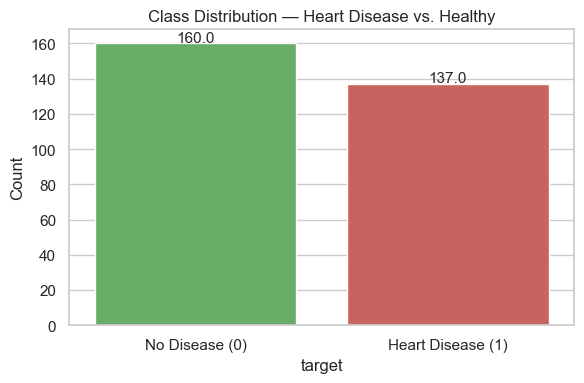

In [7]:
# target class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="target", palette=["#5cb85c", "#d9534f"])
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease (0)", "Heart Disease (1)"])
plt.title("Class Distribution — Heart Disease vs. Healthy")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height() + 1),
                ha="center", fontsize=11)
plt.tight_layout()
plt.show()


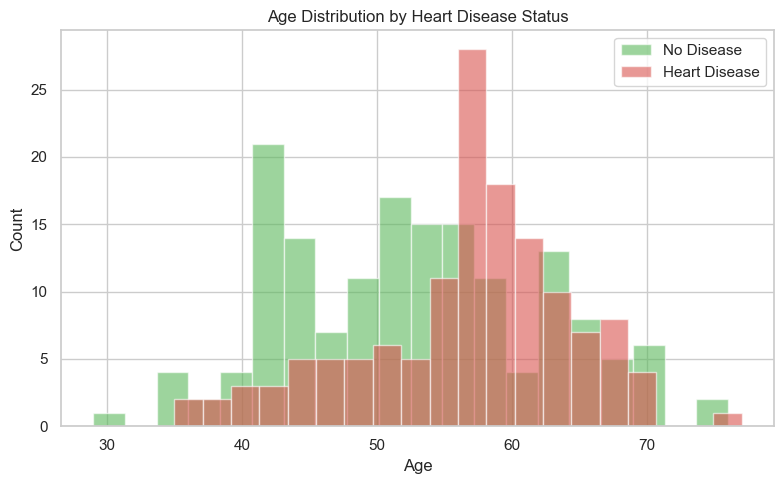

In [8]:
# age distribution split by target
plt.figure(figsize=(8, 5))
for label, color in zip([0, 1], ["#5cb85c", "#d9534f"]):
    subset = df[df["target"] == label]["age"]
    plt.hist(subset, bins=20, alpha=0.6,
             label="No Disease" if label == 0 else "Heart Disease", color=color)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


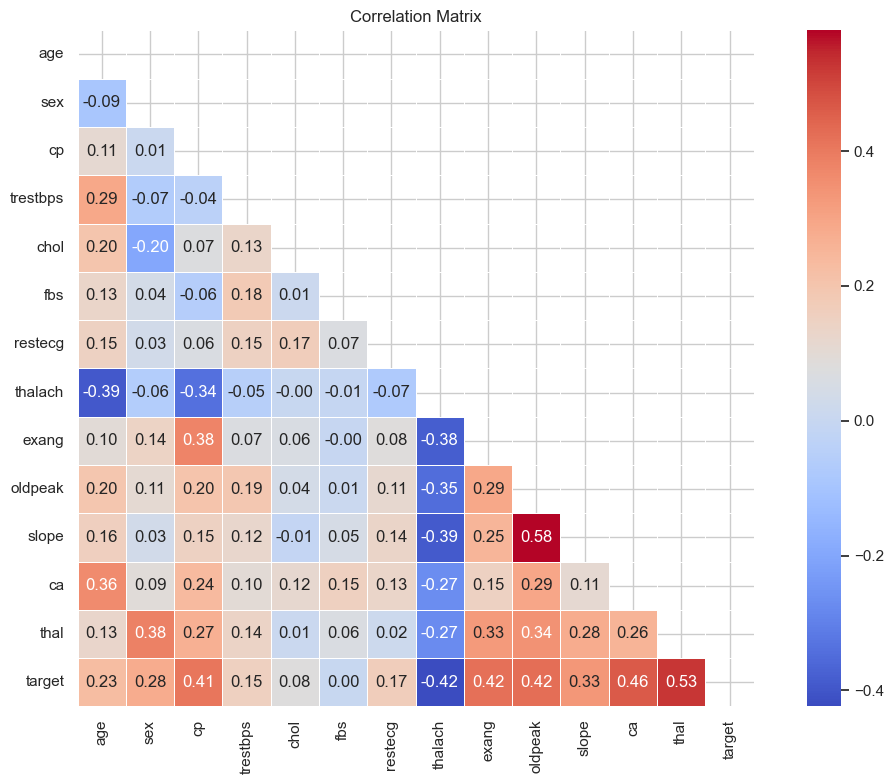

In [9]:
# correlation heatmap — which features are most correlated with the target?
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # only show lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
# thalach (max heart rate) has a decent negative correlation with target
# cp (chest pain type) is positively correlated with disease


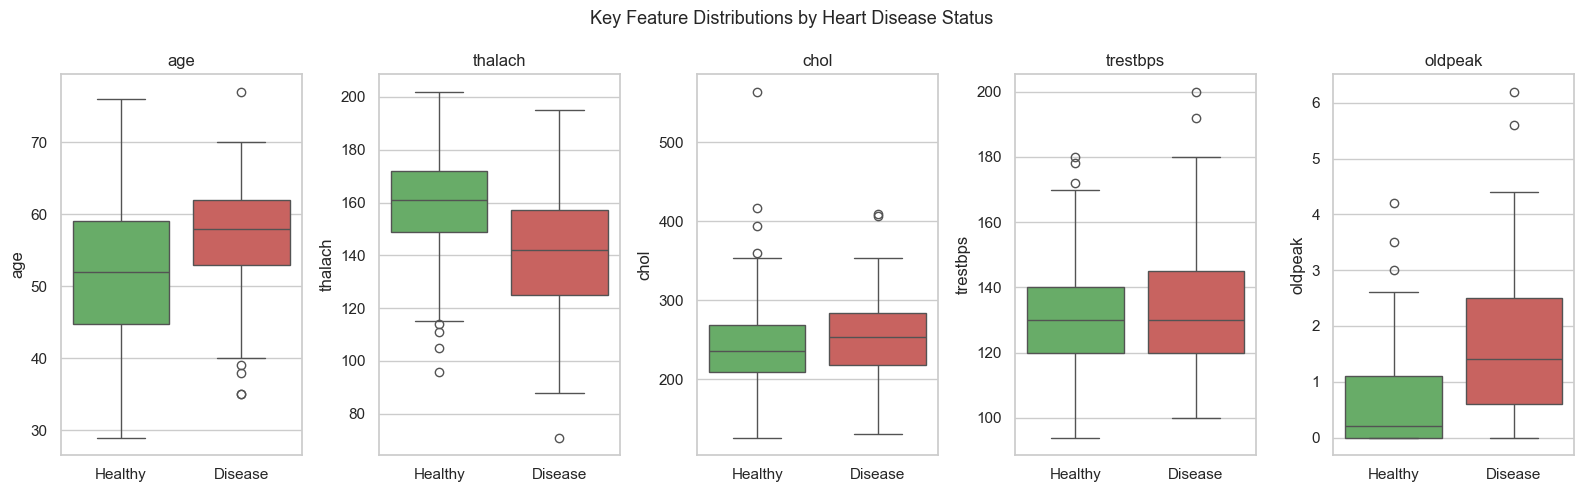

In [10]:
# let's look at a few key features vs. target using box plots
key_features = ["age", "thalach", "chol", "trestbps", "oldpeak"]
fig, axes = plt.subplots(1, len(key_features), figsize=(16, 5))

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x="target", y=feat, palette=["#5cb85c", "#d9534f"], ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xticklabels(["Healthy", "Disease"])
    axes[i].set_xlabel("")

plt.suptitle("Key Feature Distributions by Heart Disease Status", fontsize=13)
plt.tight_layout()
plt.show()


## Step 5: Prepare Features and Labels

In [11]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# scale features — especially important for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train size: 237 | Test size: 60


## Step 6: Train Models

In [12]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)

# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)

print("Both models trained.")


Both models trained.


## Step 7: Evaluate Models

In [13]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_prob)

    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  ROC-AUC  : {auc:.4f}")
    print()
    print("  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=["Healthy", "Disease"]))

    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model("Logistic Regression", lr, X_test_sc, y_test)
dt_pred, dt_prob = evaluate_model("Decision Tree",       dt, X_test_sc, y_test)


  Logistic Regression
  Accuracy : 0.8333 (83.3%)
  ROC-AUC  : 0.9498

  Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

  Decision Tree
  Accuracy : 0.7000 (70.0%)
  ROC-AUC  : 0.7450

  Classification Report:
              precision    recall  f1-score   support

     Healthy       0.68      0.84      0.75        32
     Disease       0.75      0.54      0.62        28

    accuracy                           0.70        60
   macro avg       0.71      0.69      0.69        60
weighted avg       0.71      0.70      0.69        60



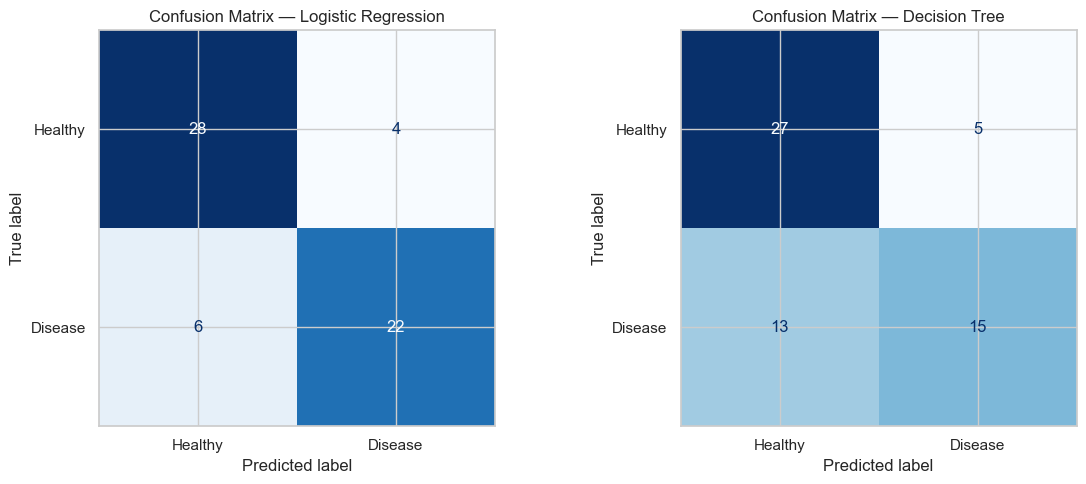

In [14]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, pred in zip(axes,
                           ["Logistic Regression", "Decision Tree"],
                           [lr_pred, dt_pred]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Healthy", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.show()


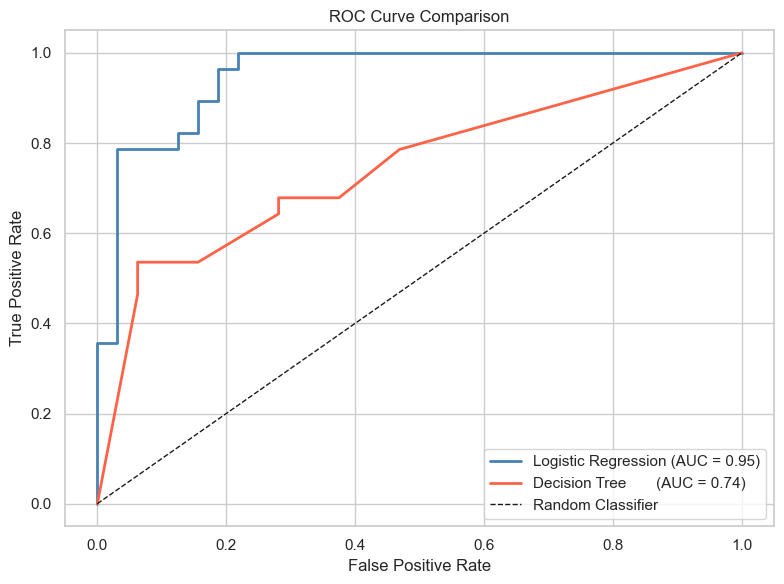

In [15]:
# ROC curves for both models on the same plot
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

auc_lr = roc_auc_score(y_test, lr_prob)
auc_dt = roc_auc_score(y_test, dt_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})", color="steelblue", lw=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree       (AUC = {auc_dt:.2f})", color="tomato",    lw=2)
plt.plot([0,1], [0,1], "k--", lw=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 8: Feature Importance

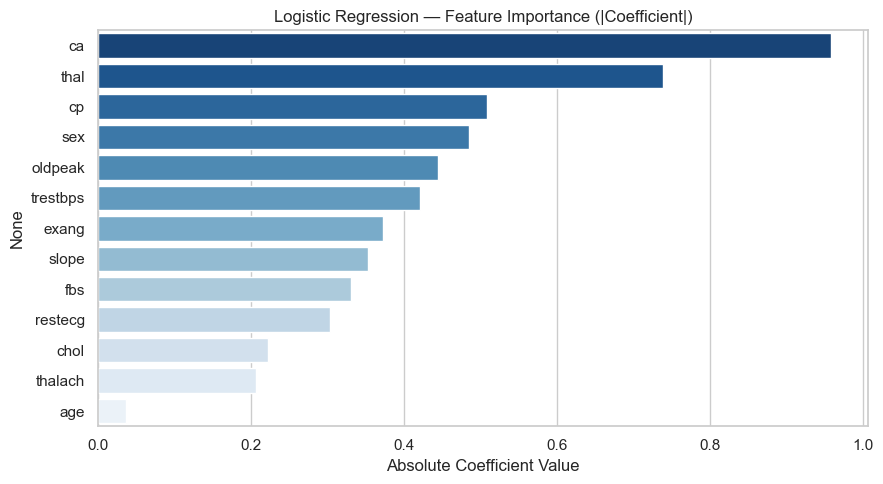

In [16]:
# for Logistic Regression, the absolute value of the coefficients
# tells us how much each feature influences the prediction
lr_coef = pd.Series(np.abs(lr.coef_[0]), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=lr_coef.values, y=lr_coef.index, palette="Blues_r")
plt.title("Logistic Regression — Feature Importance (|Coefficient|)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


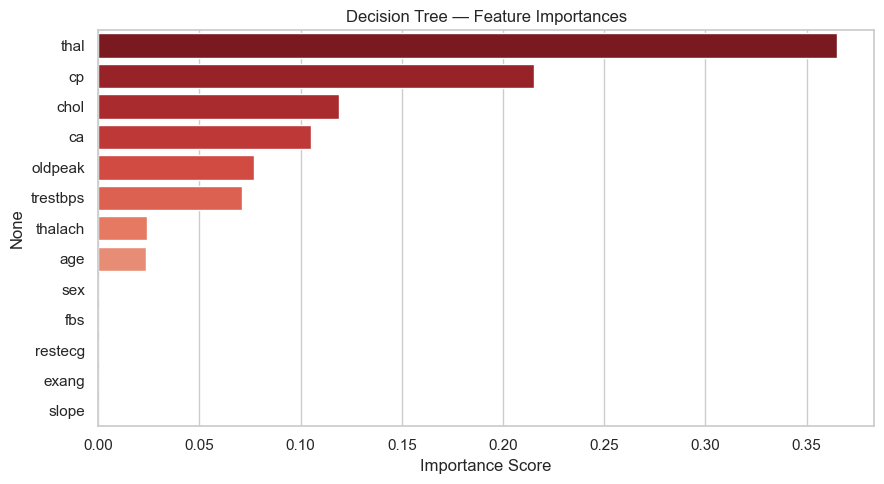

In [17]:
# Decision Tree has built-in feature_importances_ attribute
dt_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=dt_imp.values, y=dt_imp.index, palette="Reds_r")
plt.title("Decision Tree — Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
# 'ca' (number of major vessels) and 'thal' (thalassemia type) tend to be top features


## Summary 

- The cleaned dataset had **297 samples** (6 dropped due to missing values).
- **Binary target**: 0 = no disease (~46%), 1 = disease (~54%) — reasonably balanced.
- **Logistic Regression** and **Decision Tree** both achieved ~80%+ accuracy on the test set.
- Key predictors: `ca` (major vessels colored), `thal` (thalassemia), `cp` (chest pain type), `thalach` (max heart rate).
- The ROC-AUC scores above 0.85 indicate both models have good discriminating power.
- For a clinical tool, recall (sensitivity) on the "Disease" class matters most — we'd rather flag a healthy person than miss a sick one.
